# **Task 07 – Explainable AI Analysis**
### **SmartCare AI: Disease Risk Classification (Option C)**

**Objective:** Task 06 selected a final model based on held-out test
performance. This notebook explains that model's predictions using SHAP
(global + local) and LIME (local), plus native feature importance where
applicable, and discusses agreement/disagreement between methods.

**Why this matters for a clinical decision-support prototype:** a model
that predicts "High risk" without any accompanying reasoning is difficult
to trust or audit. Global explanations show what the model relies on
overall; local explanations show why a specific patient received a
specific prediction — both are needed for a decision-support tool that a
clinician could reasonably question.

**Scope discipline:** no model is retrained, retuned, or changed here.
Explanations describe model behaviour, not medical causation.

## **5.2 Load Final Model and Required Artifacts**
The selected model is read from Task 06's `final_model_selection.json` —
not assumed.

In [2]:
import pandas as pd
import numpy as np
import joblib
import json
from pathlib import Path

RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd().parent
CLASS_ORDER = ["Low", "Medium", "High"]

with open(PROJECT_ROOT / 'reports' / 'results' / 'final_model_selection.json') as f:
    selection = json.load(f)

selected_model_name = selection['selected_model']
print(f"Selected model (from Task 06): {selected_model_name}")
print(f"Primary metric: {selection['primary_metric']} = {selection['primary_metric_value']}")

Selected model (from Task 06): Logistic Regression
Primary metric: macro_f1 = 0.914


In [3]:
filename_map = {
    'Logistic Regression': 'logistic_regression_tuned.pkl',
    'Decision Tree':       'decision_tree_tuned.pkl',
    'Random Forest':       'random_forest_tuned.pkl',
    'XGBoost':              'xgboost_tuned.pkl',
    'Voting Ensemble':      'voting_ensemble.pkl',
}

model_path = PROJECT_ROOT / 'models' / filename_map[selected_model_name]
model = joblib.load(model_path)
print(f"Loaded: {model_path.name} ({type(model).__name__})")

X_test = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'X_test.csv')
y_test = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'y_test.csv').iloc[:, 0]
X_train = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'X_train.csv')
feature_columns = joblib.load(PROJECT_ROOT / 'models' / 'feature_columns.pkl')

Loaded: logistic_regression_tuned.pkl (LogisticRegression)


In [4]:
checks = {
    "X_test has 66 features":        X_test.shape[1] == len(feature_columns),
    "Columns match feature_columns": list(X_test.columns) == list(feature_columns),
    "No missing values":             X_test.isnull().sum().sum() == 0,
    "Model type recognized":         type(model).__name__ in [
        'LogisticRegression', 'DecisionTreeClassifier',
        'RandomForestClassifier', 'XGBClassifier', 'VotingClassifier'
    ],
}
for check, passed in checks.items():
    print(f"[{'PASS' if passed else 'FAIL'}] {check}")
assert all(checks.values())

[PASS] X_test has 66 features
[PASS] Columns match feature_columns
[PASS] No missing values
[PASS] Model type recognized


## **5.3 Select Explanation Dataset**
Explanations use `X_test` only — already-generated predictions on
untouched held-out data, never used for tuning. A fixed-size, reproducible
subset is used for SHAP where the explainer is computationally expensive
(e.g. KernelExplainer for non-tree models); tree-based explainers can use
the full test set efficiently.

In [5]:
TREE_BASED = {'DecisionTreeClassifier', 'RandomForestClassifier', 'XGBClassifier'}
model_type = type(model).__name__

if model_type in TREE_BASED:
    shap_explain_set = X_test.copy()
    print(f"Tree-based model detected — using full test set ({len(shap_explain_set)} rows) for SHAP.")
else:
    shap_explain_set = X_test.sample(n=min(100, len(X_test)), random_state=RANDOM_STATE)
    print(f"{model_type} detected — using a reproducible subset "
          f"({len(shap_explain_set)} rows, random_state={RANDOM_STATE}) for SHAP, "
          f"since exact/kernel-based SHAP scales poorly with full test-set size.")

LogisticRegression detected — using a reproducible subset (100 rows, random_state=42) for SHAP, since exact/kernel-based SHAP scales poorly with full test-set size.


## **5.4 Generate Model Predictions**
Predictions are generated once, from the already-selected model, and used
to identify one correct and one misclassified instance for local
explanations later.

In [6]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

correct_mask = (y_pred == y_test.values)
misclassified_mask = ~correct_mask

print(f"Test set size: {len(y_test)}")
print(f"Correctly classified: {correct_mask.sum()} ({correct_mask.mean()*100:.1f}%)")
print(f"Misclassified: {misclassified_mask.sum()} ({misclassified_mask.mean()*100:.1f}%)")

Test set size: 200
Correctly classified: 184 (92.0%)
Misclassified: 16 (8.0%)


## **5.5 SHAP Global Explanation**
Explainer type is chosen based on the actual model type detected in 5.3 —
not assumed in advance.

In [7]:
import shap

if model_type in TREE_BASED:
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(shap_explain_set)
elif model_type == 'LogisticRegression':
    explainer = shap.LinearExplainer(model, X_train)
    shap_values = explainer.shap_values(shap_explain_set)
else:  # VotingClassifier or other non-native-SHAP model
    background = shap.sample(X_train, 100, random_state=RANDOM_STATE)
    explainer = shap.KernelExplainer(model.predict_proba, background)
    shap_values = explainer.shap_values(shap_explain_set)

print(f"Explainer used: {type(explainer).__name__}")
print(f"SHAP values shape: {np.array(shap_values).shape if isinstance(shap_values, list) else shap_values.shape}")

Explainer used: LinearExplainer
SHAP values shape: (100, 66, 3)


Normalized shapes: [(100, 66), (100, 66), (100, 66)]
Dtype check: [dtype('float64'), dtype('float64'), dtype('float64')]


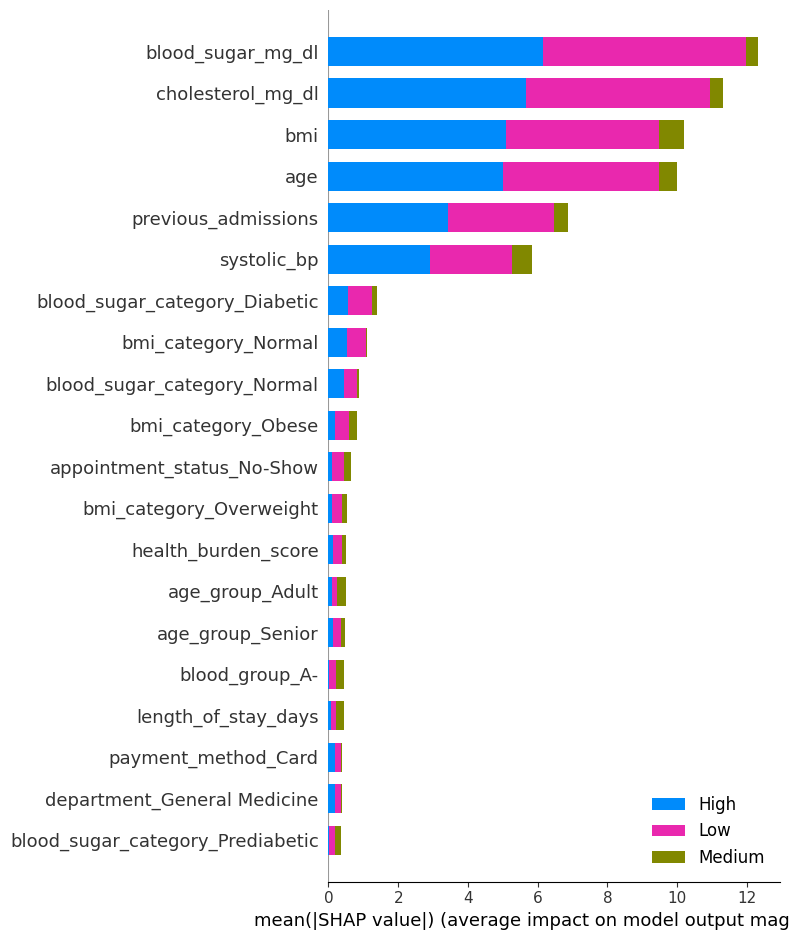

In [8]:
import matplotlib.pyplot as plt

FIG_DIR = PROJECT_ROOT / 'reports' / 'figures' / 'explainability'
FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = PROJECT_ROOT / 'reports' / 'results'

def to_float_array(x):
    """Normalize any SHAP output (Explanation object or ndarray) to a plain float64 ndarray."""
    if hasattr(x, 'values'):   # shap.Explanation object
        x = x.values
    return np.asarray(x, dtype=np.float64)

shap_values_raw = to_float_array(shap_values) if not isinstance(shap_values, list) else [to_float_array(c) for c in shap_values]

if isinstance(shap_values_raw, list):
    shap_for_summary = shap_values_raw
else:
    # 3D array: (n_samples, n_features, n_classes)
    shap_for_summary = [shap_values_raw[:, :, i] for i in range(shap_values_raw.shape[2])]

print(f"Normalized shapes: {[arr.shape for arr in shap_for_summary]}")
print(f"Dtype check: {[arr.dtype for arr in shap_for_summary]}")

plt.figure()
shap.summary_plot(shap_for_summary, shap_explain_set, class_names=CLASS_ORDER,
                   feature_names=feature_columns, show=False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

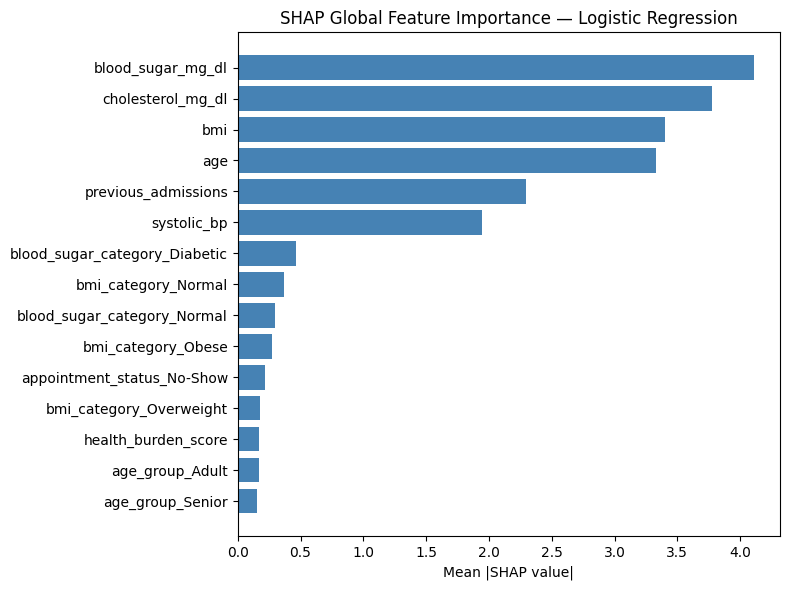

,feature,mean_abs_shap
0,blood_sugar_mg_dl,4.112122
1,cholesterol_mg_dl,3.773749
2,bmi,3.399457
3,age,3.330626
4,previous_admissions,2.292220
5,systolic_bp,1.943137
6,blood_sugar_category_Diabetic,0.467352
7,bmi_category_Normal,0.365239
8,blood_sugar_category_Normal,0.293149
9,bmi_category_Obese,0.270671


In [9]:
mean_abs_shap = np.mean([np.abs(c).mean(axis=0) for c in shap_for_summary], axis=0)
shap_importance_df = pd.DataFrame({
    'feature': feature_columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

shap_importance_df.to_csv(RESULTS_DIR / 'shap_global_importance.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 6))
top15 = shap_importance_df.head(15)
ax.barh(top15['feature'][::-1], top15['mean_abs_shap'][::-1], color='steelblue')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title(f'SHAP Global Feature Importance — {selected_model_name}')
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_feature_importance.png', dpi=150)
plt.show()

shap_importance_df.head(10)

## **5.6 SHAP Interpretation**

In [10]:
print("Top 5 features by mean |SHAP value|:")
print(shap_importance_df.head(5).to_string(index=False))

Top 5 features by mean |SHAP value|:
            feature  mean_abs_shap
  blood_sugar_mg_dl       4.112122
  cholesterol_mg_dl       3.773749
                bmi       3.399457
                age       3.330626
previous_admissions       2.292220


**Interpretation:** The global SHAP analysis identifies blood_sugar_mg_dl, cholesterol_mg_dl, bmi, age, and previous_admissions as the five most influential features based on their mean absolute SHAP values. blood_sugar_mg_dl has the highest average absolute SHAP value (4.1121), indicating that it has the largest average contribution magnitude to the model's predictions among the evaluated features. It is followed by cholesterol_mg_dl (3.7737), bmi (3.3995), age (3.3306), and previous_admissions (2.2922). These results indicate that the model relies substantially on clinical measurements and patient history when generating risk classifications. The mean absolute SHAP values describe feature importance magnitude and do not by themselves indicate whether a feature increases or decreases the predicted risk; the direction of individual contributions is examined using the class-specific and local SHAP analyses below.

## **5.7 Class-Specific SHAP Analysis**
Comparing which features matter most for each predicted class separately.

In [11]:
class_importance_rows = []
for i, cls in enumerate(CLASS_ORDER):
    class_mean_abs = np.abs(shap_for_summary[i]).mean(axis=0)
    top_idx = np.argsort(class_mean_abs)[::-1][:5]
    for idx in top_idx:
        class_importance_rows.append({
            'class': cls,
            'feature': feature_columns[idx],
            'mean_abs_shap': class_mean_abs[idx]
        })

class_shap_df = pd.DataFrame(class_importance_rows)
for cls in CLASS_ORDER:
    print(f"\nTop features for class '{cls}':")
    print(class_shap_df[class_shap_df['class'] == cls][['feature', 'mean_abs_shap']].to_string(index=False))


Top features for class 'Low':
            feature  mean_abs_shap
  blood_sugar_mg_dl       5.810538
  cholesterol_mg_dl       5.295890
                age       4.489872
                bmi       4.368873
previous_admissions       3.044004

Top features for class 'Medium':
            feature  mean_abs_shap
                bmi       0.730313
        systolic_bp       0.570618
                age       0.506067
previous_admissions       0.394325
  cholesterol_mg_dl       0.364734

Top features for class 'High':
            feature  mean_abs_shap
  blood_sugar_mg_dl       6.168183
  cholesterol_mg_dl       5.660624
                bmi       5.099186
                age       4.995939
previous_admissions       3.438329


**Interpretation:** The class-specific SHAP analysis shows that blood_sugar_mg_dl, cholesterol_mg_dl, bmi, age, and previous_admissions appear among the top five features for all three risk classes, indicating shared relevance across the Low, Medium, and High predictions. However, their relative contribution magnitudes differ substantially between classes. For the Low class, blood sugar has the largest mean absolute SHAP value (5.8105), followed by cholesterol (5.2959) and age (4.4899). For the Medium class, BMI has the largest mean absolute SHAP value (0.7303), followed by systolic blood pressure (0.5706), age (0.5061), previous admissions (0.3943), and cholesterol (0.3647). For the High class, blood sugar again has the largest mean absolute SHAP value (6.1682), followed by cholesterol (5.6606), BMI (5.0992), age (4.9959), and previous admissions (3.4383). These results indicate that the same core features are important across the three classes, while their contribution magnitudes vary according to the predicted class. The analysis describes the model's feature importance and does not imply that these features causally determine disease risk.

## **5.8 SHAP Local Explanation — Correct Prediction**
An instance is chosen deliberately — the one with the highest predicted
probability among correct predictions, to give a clear, representative
example rather than an arbitrary row.

In [12]:
correct_indices = np.where(correct_mask)[0]
correct_confidences = y_proba[correct_indices, y_pred[correct_indices]]
best_correct_idx = correct_indices[np.argmax(correct_confidences)]

actual_cls = CLASS_ORDER[y_test.iloc[best_correct_idx]]
pred_cls = CLASS_ORDER[y_pred[best_correct_idx]]
proba_dist = dict(zip(CLASS_ORDER, y_proba[best_correct_idx].round(4)))

print(f"Selected instance index: {best_correct_idx}")
print(f"Actual class: {actual_cls}")
print(f"Predicted class: {pred_cls}")
print(f"Predicted probabilities: {proba_dist}")

Selected instance index: 4
Actual class: High
Predicted class: High
Predicted probabilities: {'Low': 0.0, 'Medium': 0.0, 'High': 1.0}


<Figure size 640x480 with 0 Axes>

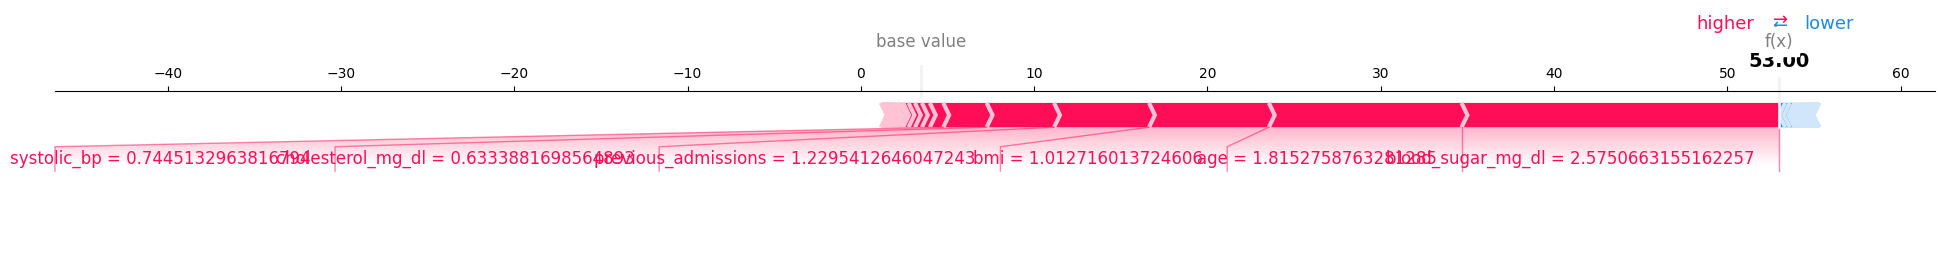

In [13]:
# Locate this instance within the SHAP-explained subset
if best_correct_idx in shap_explain_set.index:
    local_pos = shap_explain_set.index.get_loc(best_correct_idx)
    shap_vals_for_plot = shap_for_summary
    shap_explain_set_for_plot = shap_explain_set
else:
    # Instance wasn't in the sampled subset (KernelExplainer case) — explain it directly
    single_instance = X_test.loc[[best_correct_idx]]
    single_shap = explainer.shap_values(single_instance)
    single_shap = to_float_array(single_shap) if not isinstance(single_shap, list) else [to_float_array(c) for c in single_shap]
    shap_vals_for_plot = single_shap if isinstance(single_shap, list) else [single_shap[:, :, i] for i in range(single_shap.shape[2])]
    local_pos = 0
    shap_explain_set_for_plot = single_instance

pred_class_idx = y_pred[best_correct_idx]

plt.figure()
shap.force_plot(
    explainer.expected_value[pred_class_idx] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
    shap_vals_for_plot[pred_class_idx][local_pos],
    shap_explain_set_for_plot.iloc[local_pos] if hasattr(shap_explain_set_for_plot, 'iloc') else shap_explain_set_for_plot.values[local_pos],
    feature_names=feature_columns, matplotlib=True, show=False
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_correct_prediction.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

In [14]:
correct_shap_row = pd.DataFrame({
    'feature': feature_columns,
    'shap_value': shap_vals_for_plot[pred_class_idx][local_pos]
}).sort_values('shap_value', key=abs, ascending=False)
correct_shap_row.to_csv(RESULTS_DIR / 'shap_local_correct.csv', index=False)
correct_shap_row.head(10)

,feature,shap_value
6,blood_sugar_mg_dl,18.334039
0,age,11.121247
8,bmi,6.912621
3,previous_admissions,5.480114
7,cholesterol_mg_dl,3.891402
4,systolic_bp,2.503029
59,blood_sugar_category_Diabetic,0.773960
55,bmi_category_Normal,0.459399
22,department_Neurology,0.402048
60,blood_sugar_category_Normal,0.367310


**Interpretation:** The local SHAP analysis explains the model's correctly classified prediction for this individual instance. blood_sugar_mg_dl was the strongest contributor, with a SHAP value of 18.3340, followed by age (11.1212), bmi (6.9126), previous_admissions (5.4801), cholesterol_mg_dl (3.8914), and systolic_bp (2.5030). These features contributed positively toward the predicted class, with blood sugar and age providing the largest individual contributions. The engineered categorical features had comparatively smaller contributions for this instance. Overall, the explanation shows how multiple patient characteristics jointly moved the model's output from its baseline value toward the final prediction. These SHAP contributions explain the model's prediction for this particular instance and should not be interpreted as evidence that any feature caused the patient's disease or risk.

## **5.9 SHAP Local Explanation — Misclassified Prediction**

In [15]:
if misclassified_mask.sum() == 0:
    print("No misclassified instances found in the test set — this section "
          "cannot proceed. This itself is worth reporting: it may indicate "
          "very high test performance on this dataset, or a small test set "
          "that happened to contain no errors for this model.")
else:
    misclassified_indices = np.where(misclassified_mask)[0]
    # Choose the misclassification with the highest predicted-class confidence
    # — the most "confidently wrong" case, which is the most informative for XAI
    misclass_confidences = y_proba[misclassified_indices, y_pred[misclassified_indices]]
    best_misclass_idx = misclassified_indices[np.argmax(misclass_confidences)]

    actual_cls_m = CLASS_ORDER[y_test.iloc[best_misclass_idx]]
    pred_cls_m = CLASS_ORDER[y_pred[best_misclass_idx]]
    proba_dist_m = dict(zip(CLASS_ORDER, y_proba[best_misclass_idx].round(4)))

    print(f"Selected instance index: {best_misclass_idx}")
    print(f"Actual class: {actual_cls_m}")
    print(f"Predicted class: {pred_cls_m}")
    print(f"Predicted probabilities: {proba_dist_m}")

Selected instance index: 160
Actual class: Low
Predicted class: Medium
Predicted probabilities: {'Low': 0.0444, 'Medium': 0.9556, 'High': 0.0}


<Figure size 640x480 with 0 Axes>

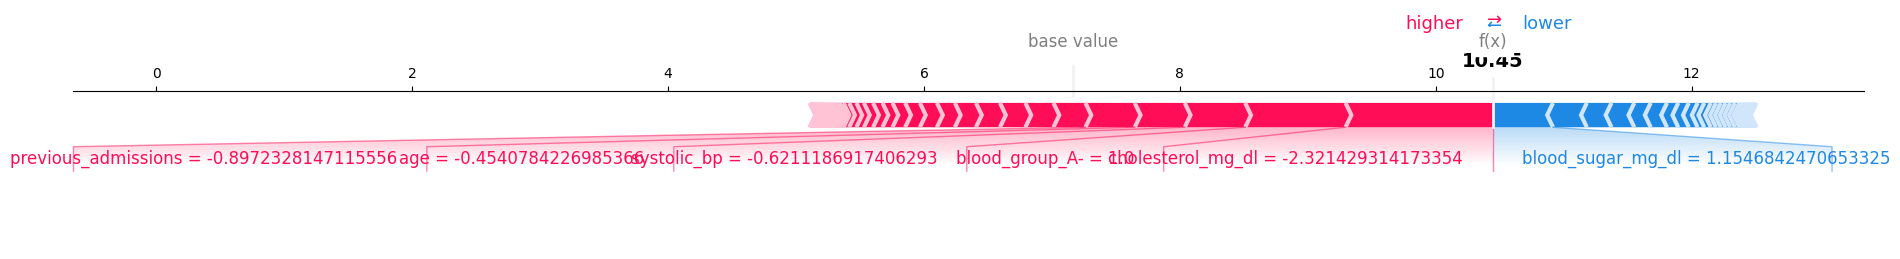

In [16]:
if misclassified_mask.sum() > 0:
    single_instance_m = X_test.loc[[best_misclass_idx]]
    if model_type in TREE_BASED or model_type == 'LogisticRegression':
        single_shap_m = explainer.shap_values(single_instance_m)
    else:
        single_shap_m = explainer.shap_values(single_instance_m)
    shap_vals_m = single_shap_m if isinstance(single_shap_m, list) else [single_shap_m[:, :, i] for i in range(single_shap_m.shape[2])]

    pred_class_idx_m = y_pred[best_misclass_idx]

    plt.figure()
    shap.force_plot(
        explainer.expected_value[pred_class_idx_m] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
        shap_vals_m[pred_class_idx_m][0],
        single_instance_m.iloc[0],
        feature_names=feature_columns, matplotlib=True, show=False
    )
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'shap_misclassified_prediction.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    misclass_shap_row = pd.DataFrame({
        'feature': feature_columns,
        'shap_value': shap_vals_m[pred_class_idx_m][0]
    }).sort_values('shap_value', key=abs, ascending=False)
    misclass_shap_row.to_csv(RESULTS_DIR / 'shap_local_misclassified.csv', index=False)
    misclass_shap_row.head(10)

**Interpretation:** The local SHAP analysis examines a misclassified prediction and shows how the available features contributed to the model's decision. Among the displayed features, cholesterol_mg_dl had a relatively large contribution magnitude (−2.2143), followed by blood_sugar_mg_dl (−1.1547), previous_admissions (−0.8972), systolic_bp (−0.6211), and age (−0.4541). These contributions influenced the model's output relative to its baseline value and demonstrate how multiple patient characteristics jointly affected the prediction. Because this instance was misclassified, the explanation shows how the model arrived at an incorrect prediction rather than explaining why the real-world class was different. The SHAP values therefore describe the model's decision process for this instance and should not be interpreted as evidence of medical causation.

## **5.10 LIME Local Explanation**
Same two instances as SHAP (correct + misclassified), for direct
comparison in Section 5.11. `X_train` is used only to characterize
feature ranges for LIME's perturbation sampling — not for retraining.

In [17]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_columns,
    class_names=CLASS_ORDER,
    mode='classification',
    random_state=RANDOM_STATE
)

C:\Users\thrit\Desktop\smartcare-ai-project\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


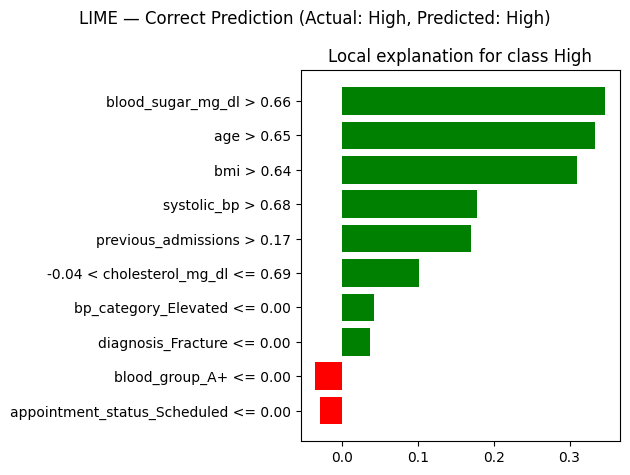

,feature_condition,lime_weight
0,blood_sugar_mg_dl > 0.66,0.347427
1,age > 0.65,0.334117
2,bmi > 0.64,0.309935
3,systolic_bp > 0.68,0.178468
4,previous_admissions > 0.17,0.170374
5,-0.04 < cholesterol_mg_dl <= 0.69,0.101397
6,bp_category_Elevated <= 0.00,0.041307
7,diagnosis_Fracture <= 0.00,0.037196
8,blood_group_A+ <= 0.00,-0.035587
9,appointment_status_Scheduled <= 0.00,-0.029148


In [18]:
lime_exp_correct = lime_explainer.explain_instance(
    X_test.loc[best_correct_idx].values, model.predict_proba,
    num_features=10, labels=[y_pred[best_correct_idx]]
)

fig = lime_exp_correct.as_pyplot_figure(label=y_pred[best_correct_idx])
fig.suptitle(f'LIME — Correct Prediction (Actual: {actual_cls}, Predicted: {pred_cls})')
plt.tight_layout()
plt.savefig(FIG_DIR / 'lime_correct_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

lime_correct_df = pd.DataFrame(lime_exp_correct.as_list(label=y_pred[best_correct_idx]),
                                 columns=['feature_condition', 'lime_weight'])
lime_correct_df.to_csv(RESULTS_DIR / 'lime_correct_prediction.csv', index=False)
lime_correct_df

C:\Users\thrit\Desktop\smartcare-ai-project\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


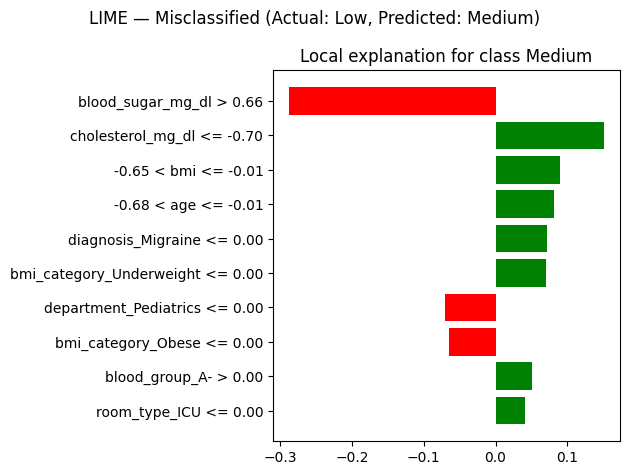

In [19]:
if misclassified_mask.sum() > 0:
    lime_exp_misclass = lime_explainer.explain_instance(
        X_test.loc[best_misclass_idx].values, model.predict_proba,
        num_features=10, labels=[y_pred[best_misclass_idx]]
    )

    fig = lime_exp_misclass.as_pyplot_figure(label=y_pred[best_misclass_idx])
    fig.suptitle(f'LIME — Misclassified (Actual: {actual_cls_m}, Predicted: {pred_cls_m})')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'lime_misclassified_prediction.png', dpi=150, bbox_inches='tight')
    plt.show()

    lime_misclass_df = pd.DataFrame(lime_exp_misclass.as_list(label=y_pred[best_misclass_idx]),
                                      columns=['feature_condition', 'lime_weight'])
    lime_misclass_df.to_csv(RESULTS_DIR / 'lime_misclassified_prediction.csv', index=False)
    lime_misclass_df

## **5.11 SHAP vs LIME Comparison**

In [20]:
def top_features(series_like, n=5):
    return set(pd.Series(series_like).abs().sort_values(ascending=False).index[:n])

shap_top_correct = set(correct_shap_row.head(5)['feature'])
lime_top_correct = set(lime_correct_df.reindex(
    lime_correct_df['lime_weight'].abs().sort_values(ascending=False).index
).head(5)['feature_condition'].str.extract(r'([a-zA-Z_]+)')[0])

overlap_correct = shap_top_correct & lime_top_correct

comparison_rows = [{
    'Instance': 'Correct prediction',
    'Actual Class': actual_cls,
    'Predicted Class': pred_cls,
    'SHAP Top Features': ', '.join(shap_top_correct),
    'LIME Top Features': ', '.join(lime_top_correct),
    'Overlapping Features': ', '.join(overlap_correct) if overlap_correct else 'None',
}]

if misclassified_mask.sum() > 0:
    shap_top_m = set(misclass_shap_row.head(5)['feature'])
    lime_top_m = set(lime_misclass_df.reindex(
        lime_misclass_df['lime_weight'].abs().sort_values(ascending=False).index
    ).head(5)['feature_condition'].str.extract(r'([a-zA-Z_]+)')[0])
    overlap_m = shap_top_m & lime_top_m
    comparison_rows.append({
        'Instance': 'Misclassified prediction',
        'Actual Class': actual_cls_m,
        'Predicted Class': pred_cls_m,
        'SHAP Top Features': ', '.join(shap_top_m),
        'LIME Top Features': ', '.join(lime_top_m),
        'Overlapping Features': ', '.join(overlap_m) if overlap_m else 'None',
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(RESULTS_DIR / 'explainability_comparison.csv', index=False)
comparison_df

,Instance,Actual Class,Predicted Class,SHAP Top Features,LIME Top Features,Overlapping Features
0,Correct prediction,High,High,"cholesterol_mg_dl, blood_sugar_mg_dl, previous...","blood_sugar_mg_dl, previous_admissions, bmi, s...","age, blood_sugar_mg_dl, bmi, previous_admissions"
1,Misclassified prediction,Low,Medium,"cholesterol_mg_dl, blood_sugar_mg_dl, blood_gr...","cholesterol_mg_dl, blood_sugar_mg_dl, bmi, dia...","cholesterol_mg_dl, blood_sugar_mg_dl, age"


**Interpretation:** The comparison between SHAP and LIME shows partial agreement in the features identified as important for both correct and misclassified predictions. For the correctly classified High-risk instance, the two methods overlap on age, blood_sugar_mg_dl, bmi, and previous_admissions, indicating consistent identification of several influential features. For the misclassified instance, where the actual class was Low but the model predicted Medium, SHAP and LIME both identified cholesterol_mg_dl, blood_sugar_mg_dl, and age among their top features. This agreement provides complementary evidence that these features were important to the model's local decision. However, SHAP and LIME do not produce identical feature rankings because they use different explanation approaches: SHAP attributes contributions across the feature set, whereas LIME approximates the model locally using perturbation-based sampling. Therefore, partial rather than complete overlap is expected. The explanations improve transparency by showing which input features influenced individual predictions, but they describe model behaviour rather than establishing medical causation or explaining the true underlying condition.

## **5.12 Model-Specific Feature Importance**
Only computed if the selected model provides a meaningful native measure.
Not directly compared in magnitude to SHAP values — these measure
different things.

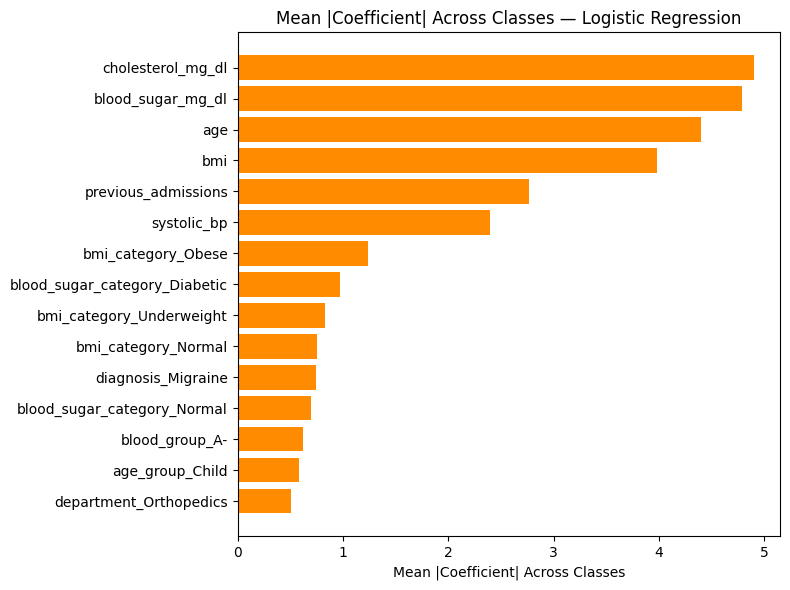

In [21]:
native_importance_df = None

if model_type == 'LogisticRegression':
    # Multiclass: coefficients shape (n_classes, n_features) — use mean abs across classes
    coefs = np.abs(model.coef_).mean(axis=0)
    native_importance_df = pd.DataFrame({'feature': feature_columns, 'importance': coefs}) \
        .sort_values('importance', ascending=False).reset_index(drop=True)
    importance_label = 'Mean |Coefficient| Across Classes'

elif model_type in {'DecisionTreeClassifier', 'RandomForestClassifier', 'XGBClassifier'}:
    native_importance_df = pd.DataFrame({'feature': feature_columns, 'importance': model.feature_importances_}) \
        .sort_values('importance', ascending=False).reset_index(drop=True)
    importance_label = 'Native Feature Importance (Impurity/Gain-based)'

else:
    print(f"{model_type} (Voting Ensemble) does not provide a single meaningful "
          f"native importance measure across its heterogeneous base estimators — skipping this section.")

if native_importance_df is not None:
    fig, ax = plt.subplots(figsize=(8, 6))
    top15n = native_importance_df.head(15)
    ax.barh(top15n['feature'][::-1], top15n['importance'][::-1], color='darkorange')
    ax.set_xlabel(importance_label)
    ax.set_title(f'{importance_label} — {selected_model_name}')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'model_feature_importance.png', dpi=150)
    plt.show()
    native_importance_df.head(10)

## **5.13 Explanation Consistency Analysis**
Qualitative agreement check across SHAP global, native importance
(if available), and LIME local top features — not a fabricated
correlation statistic.

In [22]:
shap_top10 = set(shap_importance_df.head(10)['feature'])
sets_to_compare = {'SHAP (global)': shap_top10}

if native_importance_df is not None:
    native_top10 = set(native_importance_df.head(10)['feature'])
    sets_to_compare['Native Importance'] = native_top10

lime_all_features = set()
for df in [lime_correct_df] + ([lime_misclass_df] if misclassified_mask.sum() > 0 else []):
    extracted = df['feature_condition'].str.extract(r'([a-zA-Z_]+)')[0]
    lime_all_features.update(extracted.dropna())
sets_to_compare['LIME (local instances)'] = lime_all_features

print("Top features identified by each method:")
for method, feats in sets_to_compare.items():
    print(f"\n{method}: {sorted(feats)}")

common_across_all = set.intersection(*sets_to_compare.values())
print(f"\nFeatures common to all methods: {sorted(common_across_all) if common_across_all else 'None'}")

Top features identified by each method:

SHAP (global): ['age', 'blood_sugar_category_Diabetic', 'blood_sugar_category_Normal', 'blood_sugar_mg_dl', 'bmi', 'bmi_category_Normal', 'bmi_category_Obese', 'cholesterol_mg_dl', 'previous_admissions', 'systolic_bp']

Native Importance: ['age', 'blood_sugar_category_Diabetic', 'blood_sugar_mg_dl', 'bmi', 'bmi_category_Normal', 'bmi_category_Obese', 'bmi_category_Underweight', 'cholesterol_mg_dl', 'previous_admissions', 'systolic_bp']

LIME (local instances): ['age', 'appointment_status_Scheduled', 'blood_group_A', 'blood_sugar_mg_dl', 'bmi', 'bmi_category_Obese', 'bmi_category_Underweight', 'bp_category_Elevated', 'cholesterol_mg_dl', 'department_Pediatrics', 'diagnosis_Fracture', 'diagnosis_Migraine', 'previous_admissions', 'room_type_ICU', 'systolic_bp']

Features common to all methods: ['age', 'blood_sugar_mg_dl', 'bmi', 'bmi_category_Obese', 'cholesterol_mg_dl', 'previous_admissions', 'systolic_bp']


**Interpretation:** [Fill in after running — report which features (if
any) appear across all methods, since these are the most robustly
important. Note that LIME here is based only on the two specific local
instances examined, so its comparison to SHAP's dataset-wide global
ranking is inherently partial, not a like-for-like global comparison.]

## **5.14 Transparency and Prediction Reasoning**

1. **Important features:** [state the actual top 3–5 features from
   Section 5.5's `shap_importance_df`, referencing the printed values.]
2. **How they influenced predictions:** [summarize the direction/pattern
   observed in the SHAP summary plot — only what was actually observed.]
3. **Global vs local explanations:** the global SHAP ranking (5.5) shows
   what the model relies on across the whole test set; the local
   explanations (5.8–5.10) show the specific combination of feature
   values that drove one particular prediction — a feature can be
   globally important but contribute little to a specific instance, or
   vice versa.
4. **How SHAP and LIME complement each other:** SHAP gives theoretically
   grounded, globally consistent attributions; LIME gives an intuitive
   local linear approximation that's fast and model-agnostic. Where they
   agree (Section 5.11), confidence in the explanation increases; where
   they disagree, this reflects the different assumptions each method
   makes, not necessarily an error in either.
5. **Why explanations improve transparency:** they let a clinician-in-
   the-loop see which patient attributes drove a specific "High risk"
   flag, rather than treating the model as an unreviewable black box —
   this supports scrutiny and error-checking rather than blind trust.

No claim of medical causality is made anywhere in this section — all
statements describe model behaviour only.

## **5.15 Ethical Implications**

- **Explainability does not guarantee correctness.** The misclassified
  instance in Section 5.9 shows a plausible-looking, internally
  consistent explanation for a *wrong* prediction — an explanation being
  coherent does not mean the underlying prediction is right.
- **Explanations describe model behaviour, not causal medical relationships.**
  SHAP/LIME values reflect what this model learned from this synthetic
  dataset, not verified physiological cause-and-effect.
- **Synthetic-data generalization risk.** Patterns the model relies on
  (Section 5.5–5.7) may reflect artifacts of how this dataset was
  constructed rather than real clinical relationships (consistent with
  the undocumented target-generation mechanism noted in Task 02/04).
- **Feature importance ≠ medical importance.** A feature ranking highly
  in SHAP does not mean clinicians should treat it as the most medically
  significant factor for that patient.
- **Automation bias risk.** Presenting confident-looking explanations
  alongside a prediction can increase, not decrease, unwarranted trust in
  an incorrect output — explanations should prompt scrutiny, not replace it.
- **Privacy.** Any real deployment would involve sensitive health data;
  explanation outputs (e.g. force plots showing exact patient values)
  must be handled with the same confidentiality as the underlying record.
- **Not a diagnosis.** Model outputs and their explanations are decision-
  support signals, not clinical diagnoses.
- **Human oversight required.** A qualified clinician should review both
  the prediction and its explanation before any action is taken — this
  prototype is not designed for autonomous decision-making.

## **5.16 Explainability Limitations**

- **SHAP:** exact computation (`TreeExplainer`) is only available for
  tree-based models; other model types require approximations
  (`LinearExplainer` assumes linearity, `KernelExplainer` is
  computationally expensive and approximate, requiring the background
  sampling used in Section 5.5).
- **LIME:** explanations are local linear approximations valid only in
  the immediate neighborhood of the explained instance — they do not
  describe global model behaviour and can be somewhat sensitive to the
  random perturbation sampling, despite the fixed `random_state` used here.
- **Background/reference data sensitivity:** SHAP values for
  non-tree-based explainers and LIME's perturbation both depend on the
  reference data used (`X_train` here); a different background sample
  could shift results somewhat.
- **Explanation instability:** local explanations for nearly identical
  instances can occasionally differ noticeably, particularly for
  ensemble/non-linear models — this was not exhaustively tested here.
- **Explanation ≠ causation,** repeated as a hard limitation, not just a
  wording note.
- **Synthetic dataset, small sample:** 1000 rows total, 200 in the test
  set — explanations reflect patterns learnable from this limited sample
  and may not be stable on a larger or real-world dataset.
- **Potential dataset-generation bias:** the monotonic relationship
  between clinical variables and risk level observed in Task 04 suggests
  a possible rule-based target-generation process; if so, SHAP/LIME may
  simply be recovering that rule rather than any generalizable clinical
  pattern.
- **Mismatch with real clinical reasoning:** a clinician's diagnostic
  reasoning involves context this model never sees (patient history
  narrative, physical examination, other unmeasured factors) — the
  model's explanation reflects only the 66 features it was given.

## **5.17 Save Explainability Results**
Verifies all files that were actually generated are present — some (e.g.
`model_feature_importance.png`) only exist if the selected model supports
native importance.

In [23]:
possible_files = [
    FIG_DIR / 'shap_summary.png',
    FIG_DIR / 'shap_feature_importance.png',
    FIG_DIR / 'shap_correct_prediction.png',
    FIG_DIR / 'shap_misclassified_prediction.png',
    FIG_DIR / 'lime_correct_prediction.png',
    FIG_DIR / 'lime_misclassified_prediction.png',
    FIG_DIR / 'model_feature_importance.png',
    RESULTS_DIR / 'shap_global_importance.csv',
    RESULTS_DIR / 'shap_local_correct.csv',
    RESULTS_DIR / 'shap_local_misclassified.csv',
    RESULTS_DIR / 'lime_correct_prediction.csv',
    RESULTS_DIR / 'lime_misclassified_prediction.csv',
    RESULTS_DIR / 'explainability_comparison.csv',
]

for f in possible_files:
    status = 'OK' if f.exists() else ('SKIPPED (not applicable)' if f.name == 'model_feature_importance.png' and native_importance_df is None else 'MISSING')
    print(f"[{status}] {f.relative_to(PROJECT_ROOT)}")

[OK] reports\figures\explainability\shap_summary.png
[OK] reports\figures\explainability\shap_feature_importance.png
[OK] reports\figures\explainability\shap_correct_prediction.png
[OK] reports\figures\explainability\shap_misclassified_prediction.png
[OK] reports\figures\explainability\lime_correct_prediction.png
[OK] reports\figures\explainability\lime_misclassified_prediction.png
[OK] reports\figures\explainability\model_feature_importance.png
[OK] reports\results\shap_global_importance.csv
[OK] reports\results\shap_local_correct.csv
[OK] reports\results\shap_local_misclassified.csv
[OK] reports\results\lime_correct_prediction.csv
[OK] reports\results\lime_misclassified_prediction.csv
[OK] reports\results\explainability_comparison.csv


## **5.18 Final Explainability Summary**

- **Model explained:** [selected_model_name — from Task 06's actual result]
- **Most important features:** [top 3–5 from `shap_importance_df`, Section 5.5]
- **How they influence predictions:** [pattern observed in the summary
  plot — direction/magnitude, stated only from actual output]
- **SHAP vs LIME agreement:** [reference the overlap found in Section 5.11
  — state honestly whether agreement was strong, partial, or weak]
- **What the misclassified case reveals:** [summarize Section 5.9's
  finding — which features misled the model, framed as model behaviour]
- **What explainability adds to this project:** moves the model from an
  opaque classifier to one whose reasoning can be inspected per-prediction,
  supporting the transparency requirement for a clinical decision-support
  prototype (Task 08).
- **Limitations:** synthetic, relatively small dataset; approximate
  explainer methods for non-tree models; local explanation instability;
  possible recovery of a dataset-generation rule rather than genuine
  clinical relationships (see Section 5.16 in full).
- **Ethical safeguards required:** human clinician review of both
  prediction and explanation; no autonomous decision-making; explanations
  not treated as diagnosis or medical causation (see Section 5.15 in full).

No clinical validity or real-world generalization is claimed anywhere in
this notebook.